# Bridge-rule sensitivity investigation

This notebook audits the completed Della runs for the three physical-bridge rules:

- **approach** (`positive_layer_20260814_approach`): retain a bridge structure when at least two landing nodes are dry;
- **intersect** (`positive_layer_20260814_intersect`): remove each bridge-like segment that geometrically intersects the SLR polygon;
- **retain** (`positive_layer_20260814_retain`): retain every bridge-like segment.

The analysis separates total road removals from bridge-only removals, compares physical-structure decisions, and measures downstream changes in block access status. Existing run files are read only.

In [1]:
from __future__ import annotations

import importlib.util
import json
from html import escape
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import SVG, display

# Work whether the notebook is launched from the repository root or scripts/.
START = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in (START, *START.parents)
    if (p / "scripts" / "02_access_flags.py").exists()
)
RUN_ROOT = PROJECT_ROOT / "data" / "processed" / "access" / "edited" / "della_runs"
RUN_DIRS = {
    "approach": RUN_ROOT / "positive_layer_20260814_approach",
    "intersect": RUN_ROOT / "positive_layer_20260814_intersect",
    "retain": RUN_ROOT / "positive_layer_20260814_retain",
}
RULE_ORDER = ["retain", "approach", "intersect"]
RULE_COLORS = {"retain": "#2a9d8f", "approach": "#e9c46a", "intersect": "#e76f51"}
STATUS_ORDER = ["redundant", "fragile", "isolated", "inundated", "unclassified"]

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def line_chart(series, *, title, ylabel, width=760, height=390):
    """Render a dependency-free SVG line chart from {label: (x_values, y_values, color)}."""
    left, right, top, bottom = 82, 24, 52, 62
    xs = np.asarray([v for x, _, _ in series.values() for v in x], dtype=float)
    ys = np.asarray([v for _, y, _ in series.values() for v in y], dtype=float)
    xmin, xmax = xs.min(), xs.max()
    ymin, ymax = min(0.0, ys.min()), ys.max()
    if ymax == ymin: ymax = ymin + 1
    px = lambda x: left + (x - xmin) / (xmax - xmin or 1) * (width-left-right)
    py = lambda y: top + (ymax-y) / (ymax-ymin) * (height-top-bottom)
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
             '<style>text{font-family:Arial,sans-serif;fill:#222}.axis{stroke:#555}.grid{stroke:#ddd;stroke-width:1}</style>',
             f'<text x="{width/2}" y="24" text-anchor="middle" font-size="17" font-weight="bold">{escape(title)}</text>']
    for tick in np.linspace(ymin, ymax, 5):
        y = py(tick); parts += [f'<line class="grid" x1="{left}" x2="{width-right}" y1="{y}" y2="{y}"/>', f'<text x="{left-8}" y="{y+4}" text-anchor="end" font-size="11">{tick:,.0f}</text>']
    for tick in sorted(set(xs)):
        x = px(tick); parts += [f'<text x="{x}" y="{height-bottom+22}" text-anchor="middle" font-size="11">{tick:g}</text>']
    parts += [f'<line class="axis" x1="{left}" x2="{width-right}" y1="{height-bottom}" y2="{height-bottom}"/>', f'<text transform="translate(18 {height/2}) rotate(-90)" text-anchor="middle" font-size="12">{escape(ylabel)}</text>', f'<text x="{(left+width-right)/2}" y="{height-10}" text-anchor="middle" font-size="12">SLR (ft)</text>']
    for j, (label, (xv, yv, color)) in enumerate(series.items()):
        points = ' '.join(f'{px(x):.1f},{py(y):.1f}' for x, y in zip(xv, yv))
        parts.append(f'<polyline points="{points}" fill="none" stroke="{color}" stroke-width="3"/>')
        parts.extend(f'<circle cx="{px(x):.1f}" cy="{py(y):.1f}" r="4" fill="{color}"/>' for x, y in zip(xv, yv))
        lx, ly = left + j*170, 42
        parts += [f'<line x1="{lx}" x2="{lx+25}" y1="{ly}" y2="{ly}" stroke="{color}" stroke-width="3"/>', f'<text x="{lx+31}" y="{ly+4}" font-size="11">{escape(str(label))}</text>']
    parts.append('</svg>')
    display(SVG(''.join(parts)))

def stacked_bar_chart(frame, *, title, ylabel, colors):
    x = np.asarray(frame.index, dtype=float); totals = frame.sum(axis=1).to_numpy(dtype=float)
    width, height, left, right, top, bottom = 760, 390, 82, 24, 52, 62
    ymax = max(1.0, totals.max()); bar_w = (width-left-right) / max(1, len(x)) * 0.65
    px = lambda j: left + (j+0.5)*(width-left-right)/len(x)
    py = lambda y: top + (ymax-y)/ymax*(height-top-bottom)
    parts=[f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}"><style>text{{font-family:Arial,sans-serif;fill:#222}}</style>', f'<text x="{width/2}" y="24" text-anchor="middle" font-size="17" font-weight="bold">{escape(title)}</text>']
    for tick in np.linspace(0,ymax,5):
        y=py(tick); parts += [f'<line x1="{left}" x2="{width-right}" y1="{y}" y2="{y}" stroke="#ddd"/>',f'<text x="{left-8}" y="{y+4}" text-anchor="end" font-size="11">{tick:,.0f}</text>']
    for j, idx in enumerate(frame.index):
        cumulative=0.0
        for col,color in zip(frame.columns,colors):
            value=float(frame.loc[idx,col]); y1=py(cumulative+value); y0=py(cumulative)
            parts.append(f'<rect x="{px(j)-bar_w/2}" y="{y1}" width="{bar_w}" height="{y0-y1}" fill="{color}"/>'); cumulative += value
        parts.append(f'<text x="{px(j)}" y="{height-bottom+22}" text-anchor="middle" font-size="11">{idx}</text>')
    parts.append(f'<text transform="translate(18 {height/2}) rotate(-90)" text-anchor="middle" font-size="12">{escape(ylabel)}</text>')
    for j,(col,color) in enumerate(zip(frame.columns,colors)):
        lx=left+j*230; parts += [f'<rect x="{lx}" y="34" width="12" height="12" fill="{color}"/>',f'<text x="{lx+17}" y="45" font-size="11">{escape(str(col))}</text>']
    parts.append('</svg>'); display(SVG(''.join(parts)))

def heatmap(table, *, title):
    cell_w, cell_h, left, top = 120, 50, 125, 75
    width, height = left+cell_w*len(table.columns)+30, top+cell_h*len(table.index)+30
    vmax=max(1,int(table.to_numpy().max())); parts=[f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}"><style>text{{font-family:Arial,sans-serif;fill:#222}}</style>',f'<text x="{width/2}" y="24" text-anchor="middle" font-size="16" font-weight="bold">{escape(title)}</text>']
    for j,col in enumerate(table.columns): parts.append(f'<text x="{left+(j+.5)*cell_w}" y="{top-12}" text-anchor="middle" font-size="11">{escape(str(col))}</text>')
    for i,idx in enumerate(table.index):
        parts.append(f'<text x="{left-8}" y="{top+(i+.55)*cell_h}" text-anchor="end" font-size="11">{escape(str(idx))}</text>')
        for j,col in enumerate(table.columns):
            v=int(table.loc[idx,col]); intensity=v/vmax; shade=int(245-170*intensity); color=f'rgb(255,{shade},{max(80,shade-30)})'
            parts += [f'<rect x="{left+j*cell_w}" y="{top+i*cell_h}" width="{cell_w}" height="{cell_h}" fill="{color}" stroke="white"/>',f'<text x="{left+(j+.5)*cell_w}" y="{top+(i+.58)*cell_h}" text-anchor="middle" font-size="13">{v:,}</text>']
    parts.append('</svg>'); display(SVG(''.join(parts)))

print(f"Project root: {PROJECT_ROOT}")
print(f"Run root:     {RUN_ROOT}")

Project root: C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access
Run root:     C:\Users\Vivek\Dropbox\repos\slr_fl_fragile_access\data\processed\access\edited\della_runs


## 1. Validate the three run configurations

The manifest is the authoritative record of the flags used on Della. This check also verifies seven complete scenarios and 70,695 rows per scenario.

In [2]:
manifests = {}
manifest_rows = []
for expected_rule, run_dir in RUN_DIRS.items():
    manifest_path = run_dir / "run_manifest.json"
    assert manifest_path.exists(), f"Missing {manifest_path}"
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    manifests[expected_rule] = manifest
    flags = manifest["cli_flags"]
    row_counts = {int(k): int(v) for k, v in manifest["row_counts_by_scenario"].items()}
    manifest_rows.append({
        "directory": run_dir.name,
        "bridge_rule": flags["bridge_rule"],
        "legacy_mode": flags["legacy_mode"],
        "legacy_layer_gate": flags["legacy_layer_gate"],
        "any_legacy_switch": any(bool(value) for key, value in flags.items() if key.startswith("legacy_")),
        "working_tree_dirty": manifest["git"]["working_tree_dirty"],
        "git_commit": manifest["git"]["commit"][:10],
        "scenarios": flags["scenarios"],
        "n_scenarios": len(row_counts),
        "rows_each_scenario": sorted(set(row_counts.values())),
        "utc_timestamp": manifest["utc_timestamp"],
    })
    assert flags["bridge_rule"] == expected_rule
    assert flags["legacy_mode"] is False
    assert flags["legacy_layer_gate"] is False
    assert not any(bool(value) for key, value in flags.items() if key.startswith("legacy_"))
    assert manifest["module_parameters"]["CACHE_SCHEMA_VERSION"] == 3
    assert row_counts == {ft: 70_695 for ft in range(7)}

manifest_summary = pd.DataFrame(manifest_rows)
display(manifest_summary)
print("MANIFEST VALIDATION PASSED")

,directory,bridge_rule,legacy_mode,legacy_layer_gate,any_legacy_switch,working_tree_dirty,git_commit,scenarios,n_scenarios,rows_each_scenario,utc_timestamp
0,positive_layer_20260814_approach,approach,False,False,False,True,27ac074753,"0,1,2,3,4,5,6",7,[70695],2026-08-15T02:00:11.675627+00:00
1,positive_layer_20260814_intersect,intersect,False,False,False,True,27ac074753,"0,1,2,3,4,5,6",7,[70695],2026-08-15T08:03:21.562627+00:00
2,positive_layer_20260814_retain,retain,False,False,False,True,27ac074753,"0,1,2,3,4,5,6",7,[70695],2026-08-15T05:11:14.467775+00:00


MANIFEST VALIDATION PASSED


## 2. Removed road segments: total versus bridge-only

The manifest records exact segment counts. Non-bridge removals are identical across rules because only bridge-like edges change treatment. Looking only at total removals can hide substantial disagreement about bridges, especially at high SLR levels.

,slr_ft,rule,n_non_bridge_edges_removed,n_bridge_edges_removed,n_total_edges_removed,bridge_share_of_removed_pct
0,0,approach,437,660,1097,60.16
1,0,intersect,437,1041,1478,70.43
2,0,retain,437,0,437,0.00
9,3,approach,37571,775,38346,2.02
10,3,intersect,37571,1294,38865,3.33
11,3,retain,37571,0,37571,0.00
18,6,approach,431250,1578,432828,0.36
19,6,intersect,431250,3440,434690,0.79
20,6,retain,431250,0,431250,0.00


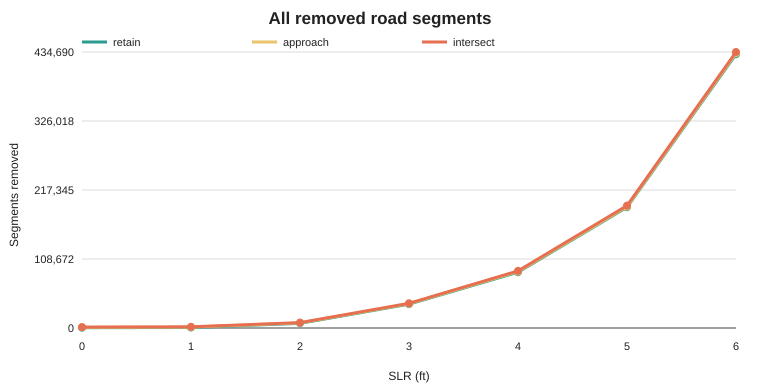

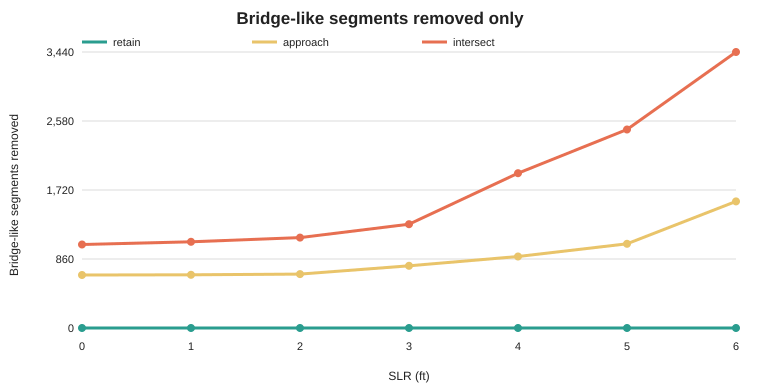

rule,approach,intersect,retain,approach_as_pct_of_intersect,intersect_minus_approach
slr_ft,,,,,
0,660,1041,0,63.40,381
1,663,1074,0,61.73,411
2,672,1127,0,59.63,455
3,775,1294,0,59.89,519
4,891,1929,0,46.19,1038
5,1050,2474,0,42.44,1424
6,1578,3440,0,45.87,1862


In [3]:
summary_frames = []
for rule, manifest in manifests.items():
    frame = pd.DataFrame(manifest["bridge_structure_counts"]).copy()
    frame["rule"] = rule
    summary_frames.append(frame)

removal_summary = pd.concat(summary_frames, ignore_index=True)
removal_summary = removal_summary.sort_values(["slr_ft", "rule"]).reset_index(drop=True)
removal_summary["bridge_share_of_removed_pct"] = (
    100 * removal_summary["n_bridge_edges_removed"] / removal_summary["n_total_edges_removed"]
)

selected_removals = removal_summary.loc[
    removal_summary["slr_ft"].isin([0, 3, 6]),
    ["slr_ft", "rule", "n_non_bridge_edges_removed", "n_bridge_edges_removed",
     "n_total_edges_removed", "bridge_share_of_removed_pct"]
].copy()
display(selected_removals)

all_series = {}
bridge_series = {}
for rule in RULE_ORDER:
    z = removal_summary.query("rule == @rule")
    all_series[rule] = (z["slr_ft"], z["n_total_edges_removed"], RULE_COLORS[rule])
    bridge_series[rule] = (z["slr_ft"], z["n_bridge_edges_removed"], RULE_COLORS[rule])
line_chart(all_series, title="All removed road segments", ylabel="Segments removed")
line_chart(bridge_series, title="Bridge-like segments removed only", ylabel="Bridge-like segments removed")

edge_pivot = removal_summary.pivot(index="slr_ft", columns="rule", values="n_bridge_edges_removed")
edge_pivot["approach_as_pct_of_intersect"] = 100 * edge_pivot["approach"] / edge_pivot["intersect"]
edge_pivot["intersect_minus_approach"] = edge_pivot["intersect"] - edge_pivot["approach"]
display(edge_pivot)

**Reading the two panels:** at 6 ft, 431,250 non-bridge segments are removed under every rule. Against that denominator, the extra 1,578 `approach` bridge removals and 3,440 `intersect` bridge removals barely separate the total-count lines. The bridge-only panel is the appropriate comparison of the bridge rules.

## 3. Physical bridge structures and rule overlap

The three rules are not a simple nested ladder at the segment level. `Intersect` removes wet deck segments even when both approaches are dry. Conversely, `approach` removes an entire bridge-like component whenever it has fewer than two dry landing nodes—even if none of its segments geometrically intersects the SLR polygon.

,both_remove,approach_only,intersect_only,neither_removes
slr_ft,,,,
0,109,91,355,2927
1,112,91,370,2909
2,121,91,385,2885
3,153,86,392,2851
4,225,79,597,2581
5,325,74,740,2343
6,515,60,893,2014


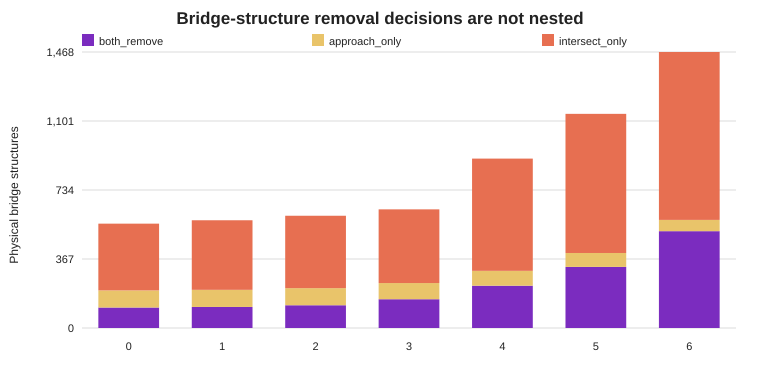

In [4]:
audit_frames = []
for rule, run_dir in RUN_DIRS.items():
    for slr_ft in range(7):
        frame = pd.read_csv(run_dir / f"bridge_structures_slr_{slr_ft}ft.csv")
        frame["rule"] = rule
        audit_frames.append(frame)
bridge_audit = pd.concat(audit_frames, ignore_index=True)

audit_by_rule = {rule: bridge_audit.query("rule == @rule").copy() for rule in RULE_ORDER}

overlap_rows = []
for slr_ft in range(7):
    a = audit_by_rule["approach"].query("slr_ft == @slr_ft").set_index("structure_id")
    i = audit_by_rule["intersect"].query("slr_ft == @slr_ft").set_index("structure_id")
    overlap_rows.append({
        "slr_ft": slr_ft,
        "both_remove": int((a["removed"] & i["removed"]).sum()),
        "approach_only": int((a["removed"] & ~i["removed"]).sum()),
        "intersect_only": int((~a["removed"] & i["removed"]).sum()),
        "neither_removes": int((~a["removed"] & ~i["removed"]).sum()),
    })
structure_overlap = pd.DataFrame(overlap_rows).set_index("slr_ft")
display(structure_overlap)

plot_cols = ["both_remove", "approach_only", "intersect_only"]
stacked_bar_chart(
    structure_overlap[plot_cols],
    title="Bridge-structure removal decisions are not nested",
    ylabel="Physical bridge structures",
    colors=["#7b2cbf", RULE_COLORS["approach"], RULE_COLORS["intersect"]],
)

## 4. Why `approach` still removes many edges at baseline

A structure with zero or one landing node can never meet the `>=2` dry-landings rule. Those structures are removed under `approach` in every scenario, whether inundation touches them or not. This is distinct from a structure that begins with at least two landings but loses landing viability to SLR.

,slr_ft,category,structures,edges,length_km
0,0,<2 total landings,98,484,10.57
1,0,">=2 total, <2 dry",102,176,6.20
6,3,<2 total landings,98,484,10.57
7,3,">=2 total, <2 dry",141,291,9.91
12,6,<2 total landings,98,484,10.57
13,6,">=2 total, <2 dry",477,1094,31.24


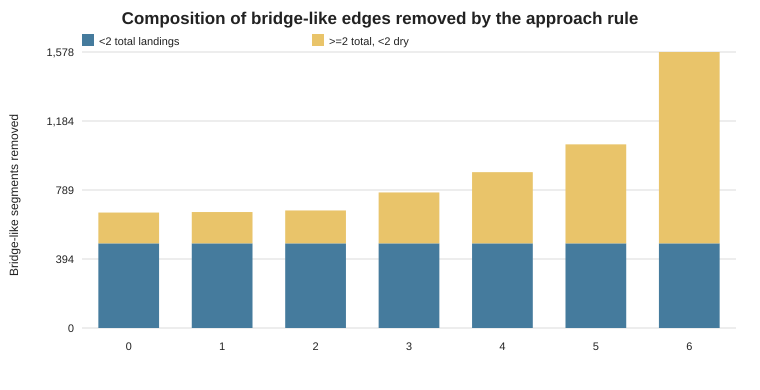

,category,structures,bridge_edges,structure_length_km,entirely_service_highway
0,Approach only,91,455,9.33,78
1,Intersect only,355,844,78.57,2


Largest baseline approach-only structures (these have <2 dry landings but no geometric intersection):


,landing_node_count,dry_landing_count,total_length_m,n_bridge_edges,n_osm_ways,highway_classes
structure_id,,,,,,
3439,0,0,"1,444.31",65,10,service
2640,1,1,818.32,32,4,service
2561,1,1,576.62,29,6,service
3448,1,1,486.38,48,5,service
3276,1,1,376.86,9,2,service
3395,1,1,249.20,10,3,service
2671,1,1,218.94,9,3,service
3098,1,1,209.50,8,1,service
3414,1,1,203.03,10,6,service


Largest baseline intersect-only structure footprints (only intersecting segments are removed):


,landing_node_count,dry_landing_count,total_length_m,n_bridge_edges,geometrically_intersecting_edge_count,n_osm_ways,highway_classes
structure_id,,,,,,,
21,14,14,"10,251.32",392,5,44,motorway|motorway_link
873,5,5,"3,487.44",44,3,7,motorway|motorway_link
874,4,4,"3,290.55",27,4,5,motorway|motorway_link
1630,4,4,"3,021.20",43,3,7,trunk|trunk_link
1631,4,4,"2,870.81",44,4,8,trunk|trunk_link
1153,3,3,"1,329.05",77,12,3,motorway|motorway_link
41,4,4,"1,320.82",22,15,7,motorway|motorway_link|trunk
939,2,2,"1,100.23",1,1,1,primary
937,2,2,"1,100.07",1,1,1,primary


In [5]:
composition_rows = []
for slr_ft in range(7):
    x = audit_by_rule["approach"].query("slr_ft == @slr_ft")
    structural = x["landing_node_count"].lt(2)
    landing_loss = x["landing_node_count"].ge(2) & x["dry_landing_count"].lt(2)
    composition_rows.extend([
        {"slr_ft": slr_ft, "category": "<2 total landings",
         "structures": int(structural.sum()), "edges": int(x.loc[structural, "n_bridge_edges"].sum()),
         "length_km": x.loc[structural, "total_length_m"].sum() / 1000},
        {"slr_ft": slr_ft, "category": ">=2 total, <2 dry",
         "structures": int(landing_loss.sum()), "edges": int(x.loc[landing_loss, "n_bridge_edges"].sum()),
         "length_km": x.loc[landing_loss, "total_length_m"].sum() / 1000},
    ])
approach_composition = pd.DataFrame(composition_rows)
display(approach_composition.query("slr_ft in [0, 3, 6]"))

stacked = approach_composition.pivot(index="slr_ft", columns="category", values="edges")
stacked_bar_chart(
    stacked[["<2 total landings", ">=2 total, <2 dry"]],
    title="Composition of bridge-like edges removed by the approach rule",
    ylabel="Bridge-like segments removed",
    colors=["#457b9d", RULE_COLORS["approach"]],
)

a0 = audit_by_rule["approach"].query("slr_ft == 0").set_index("structure_id")
i0 = audit_by_rule["intersect"].query("slr_ft == 0").set_index("structure_id")
approach_only_0 = a0.loc[a0["removed"] & ~i0["removed"]].copy()
intersect_only_0 = i0.loc[~a0["removed"] & i0["removed"]].copy()

baseline_special = pd.DataFrame([
    {"category": "Approach only", "structures": len(approach_only_0),
     "bridge_edges": int(approach_only_0["n_bridge_edges"].sum()),
     "structure_length_km": approach_only_0["total_length_m"].sum()/1000,
     "entirely_service_highway": int(approach_only_0["highway_classes"].eq("service").sum())},
    {"category": "Intersect only", "structures": len(intersect_only_0),
     "bridge_edges": int(intersect_only_0["removed_edge_count"].sum()),
     "structure_length_km": intersect_only_0["total_length_m"].sum()/1000,
     "entirely_service_highway": int(intersect_only_0["highway_classes"].eq("service").sum())},
])
display(baseline_special)

print("Largest baseline approach-only structures (these have <2 dry landings but no geometric intersection):")
display(approach_only_0.sort_values("total_length_m", ascending=False)[
    ["landing_node_count", "dry_landing_count", "total_length_m", "n_bridge_edges", "n_osm_ways", "highway_classes"]
].head(15))

print("Largest baseline intersect-only structure footprints (only intersecting segments are removed):")
display(intersect_only_0.sort_values("total_length_m", ascending=False)[
    ["landing_node_count", "dry_landing_count", "total_length_m", "n_bridge_edges",
     "geometrically_intersecting_edge_count", "n_osm_ways", "highway_classes"]
].head(15))

### Tag provenance

The cached segmentized edges let us distinguish explicit OSM bridge tags from edges classified as bridge-like only because they have a positive layer. The pipeline's own `build_bridge_structures` function is reused so the structure IDs match the Della audits; no run artifact is altered.

In [6]:
cache_dir = PROJECT_ROOT / "data" / "processed" / "access" / "cache"
cache_paths = sorted(cache_dir.glob("segmentized_edges_*_full_layer_positive_v3.parquet"))
cache_reclassified_from_v2 = False
if not cache_paths:
    cache_paths = sorted(cache_dir.glob("segmentized_edges_*_full_v2.parquet"))
if not cache_paths:
    print("Full segmentized-edge cache not present; skipping tag provenance.")
else:
    base_path = PROJECT_ROOT / "scripts" / "02_access_flags.py"
    spec = importlib.util.spec_from_file_location("access_base_for_audit", base_path)
    base = importlib.util.module_from_spec(spec)
    assert spec.loader is not None
    spec.loader.exec_module(base)

    cached_edges = base.gpd.read_parquet(cache_paths[0])
    cached_bridge_like_before_positive_gate = cached_edges["bridge_like"].astype(bool).copy()
    if "layer_positive" not in cache_paths[0].name:
        cached_edges["bridge_like"] = (
            cached_edges["bridge_tag_present"].astype(bool)
            | cached_edges["layer_value"].map(base.is_positive_layer_value)
        )
        cache_reclassified_from_v2 = True
        print("Reclassified the local v2 cache in memory with the positive-layer gate; no cache file was changed.")
    structured_edges, rebuilt_structures, _ = base.build_bridge_structures(cached_edges)
    assert len(rebuilt_structures) == len(a0)
    assert np.allclose(
        rebuilt_structures.sort_values("structure_id")["total_length_m"],
        a0.sort_index()["total_length_m"],
    )

    tag_by_structure = structured_edges.loc[structured_edges["bridge_like"]].groupby("structure_id").agg(
        any_explicit_bridge_tag=("bridge_tag_present", "any"),
        any_positive_layer=("layer_value", lambda s: s.map(base.is_positive_layer_value).any()),
        entirely_service_highway=("highway", lambda s: s.eq("service").all()),
    )
    tag_by_structure.index = tag_by_structure.index.astype(int)
    tagged_a0 = a0.join(tag_by_structure)

    provenance_masks = {
        "All <2-landing structures": tagged_a0["landing_node_count"].lt(2),
        "Approach-only at 0 ft": tagged_a0.index.isin(approach_only_0.index),
        "Approach removed, >=2 total landings": tagged_a0["removed"] & tagged_a0["landing_node_count"].ge(2),
    }
    provenance_rows = []
    for label, mask in provenance_masks.items():
        z = tagged_a0.loc[mask]
        provenance_rows.append({
            "category": label,
            "structures": len(z),
            "entirely_service_highway": int(z["entirely_service_highway"].sum()),
            "any_explicit_bridge_tag": int(z["any_explicit_bridge_tag"].sum()),
            "positive_layer_only_no_bridge_tag": int((~z["any_explicit_bridge_tag"] & z["any_positive_layer"]).sum()),
        })
    display(pd.DataFrame(provenance_rows))
    del structured_edges

Reclassified the local v2 cache in memory with the positive-layer gate; no cache file was changed.


,category,structures,entirely_service_highway,any_explicit_bridge_tag,positive_layer_only_no_bridge_tag
0,All <2-landing structures,98,80,63,35
1,Approach-only at 0 ft,91,78,56,35
2,"Approach removed, >=2 total landings",102,6,102,0


## 5. Downstream block-access consequences

Road-edge counts do not measure substantive access impact. Here the unit is a block whose `scenario_status` changes between two otherwise identical runs. Ineligible blocks remain in the data, so counts are shown both for the full output and the analysis-eligible universe.

In [7]:
long_columns = [
    "block_geoid", "slr_ft", "scenario_status", "analysis_eligible", "pop20", "county_name",
    "nearby_bridge_structure_id", "nearby_bridge_structure_distance_m",
    "nearby_bridge_structure_retained", "bridge_rule_applied",
]
long = {}
for rule, run_dir in RUN_DIRS.items():
    frame = pd.read_parquet(run_dir / "block_access_flags_long.parquet", columns=long_columns)
    assert set(frame["bridge_rule_applied"].dropna().unique()) == {rule}
    assert not frame.duplicated(["block_geoid", "slr_ft"]).any()
    long[rule] = frame.set_index(["block_geoid", "slr_ft"]).sort_index()

reference_index = long["approach"].index
assert all(frame.index.equals(reference_index) for frame in long.values())

status_counts = pd.concat(
    [frame.groupby(["slr_ft", "scenario_status"]).size().rename(rule) for rule, frame in long.items()],
    axis=1,
).fillna(0).astype(int)

print("Status counts at 0 ft and 6 ft:")
display(status_counts.loc[pd.IndexSlice[[0, 6], :], :])

Status counts at 0 ft and 6 ft:


approach  intersect  retain
slr_ft scenario_status                             
0      fragile             17729      17989   17751
       inundated            1178       1178    1178
       isolated              165        439     143
       redundant           51452      50918   51452
       unclassified          171        171     171
6      fragile             13961      13988   13970
       inundated           14729      14729   14729
       isolated             6495       6957    6486
       redundant           35395      34906   35395
       unclassified          115        115     115

,comparison,slr_ft,blocks_changed,eligible_blocks_changed,population_in_eligible_changed_blocks,changed_blocks_near_bridge,median_nearest_bridge_distance_m
0,approach vs intersect,0,747,744,51526,747,340.36
3,approach vs intersect,3,546,545,46149,533,318.80
6,approach vs intersect,6,688,681,24088,687,167.04
7,approach vs retain,0,22,21,2815,22,42.36
10,approach vs retain,3,14,14,3781,14,27.97
13,approach vs retain,6,9,9,652,9,18.83
14,intersect vs retain,0,745,741,52539,745,340.95
17,intersect vs retain,3,540,539,48394,527,323.42
20,intersect vs retain,6,681,674,23436,680,170.46


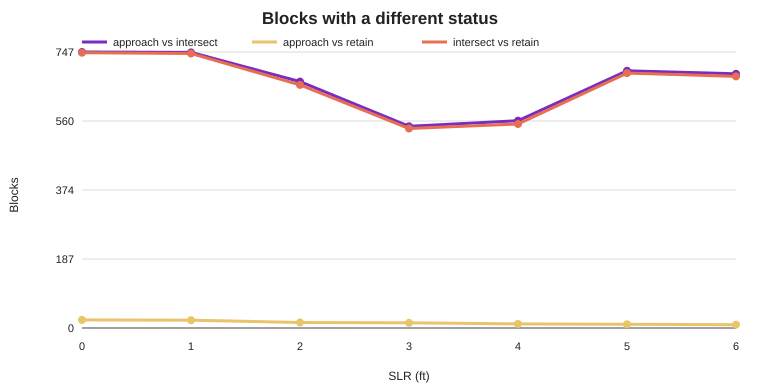

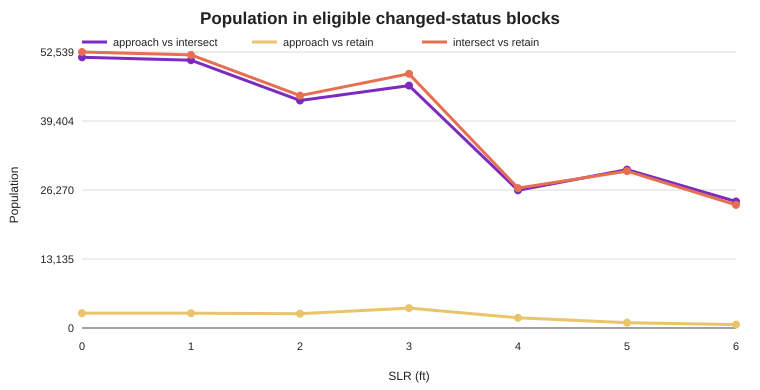

In [8]:
pair_rows = []
pairs = [("approach", "intersect"), ("approach", "retain"), ("intersect", "retain")]
for left, right in pairs:
    for slr_ft in range(7):
        a = long[left].xs(slr_ft, level="slr_ft")
        b = long[right].xs(slr_ft, level="slr_ft")
        changed = a["scenario_status"].ne(b["scenario_status"])
        eligible_changed = changed & a["analysis_eligible"]
        near = a["nearby_bridge_structure_id"].notna()
        pair_rows.append({
            "comparison": f"{left} vs {right}",
            "slr_ft": slr_ft,
            "blocks_changed": int(changed.sum()),
            "eligible_blocks_changed": int(eligible_changed.sum()),
            "population_in_eligible_changed_blocks": int(a.loc[eligible_changed, "pop20"].sum()),
            "changed_blocks_near_bridge": int((changed & near).sum()),
            "median_nearest_bridge_distance_m": a.loc[changed & near, "nearby_bridge_structure_distance_m"].median(),
        })
pairwise_impact = pd.DataFrame(pair_rows)
display(pairwise_impact.query("slr_ft in [0, 3, 6]"))

comparison_colors = {"approach vs intersect": "#7b2cbf", "approach vs retain": RULE_COLORS["approach"], "intersect vs retain": RULE_COLORS["intersect"]}
block_series = {}
pop_series = {}
for comparison, z in pairwise_impact.groupby("comparison"):
    block_series[comparison] = (z["slr_ft"], z["blocks_changed"], comparison_colors[comparison])
    pop_series[comparison] = (z["slr_ft"], z["population_in_eligible_changed_blocks"], comparison_colors[comparison])
line_chart(block_series, title="Blocks with a different status", ylabel="Blocks")
line_chart(pop_series, title="Population in eligible changed-status blocks", ylabel="Population")

### Status-count differences relative to `retain`

This view identifies which access classes actually move. A zero line means that rule produces the same count as the retain-all upper bound for that status and SLR level.

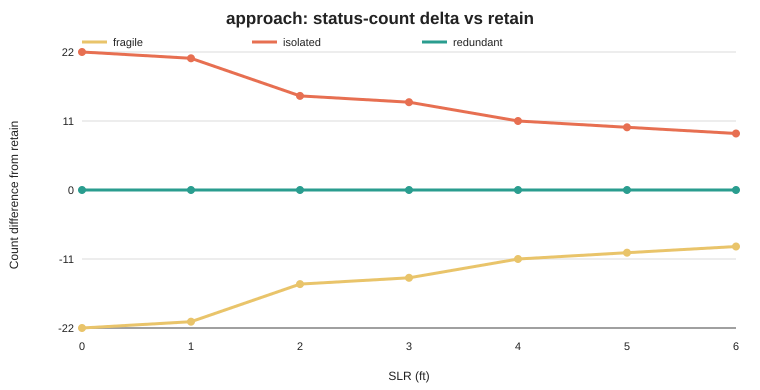

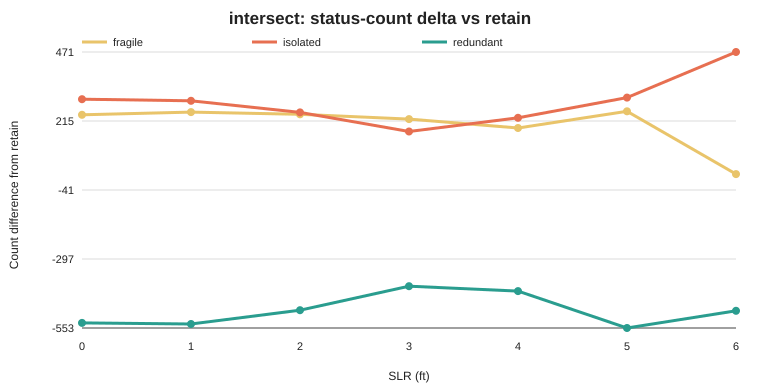

rule                    approach  intersect
slr_ft scenario_status                     
0      fragile               -22        238
       inundated               0          0
       isolated               22        296
       redundant               0       -534
       unclassified            0          0
6      fragile                -9         18
       inundated               0          0
       isolated                9        471
       redundant               0       -489
       unclassified            0          0

In [9]:
count_table = status_counts.reset_index().melt(
    id_vars=["slr_ft", "scenario_status"], var_name="rule", value_name="count"
)
retain_counts = count_table.query("rule == 'retain'")[["slr_ft", "scenario_status", "count"]].rename(columns={"count": "retain_count"})
deltas = count_table.merge(retain_counts, on=["slr_ft", "scenario_status"], validate="many_to_one")
deltas["delta_vs_retain"] = deltas["count"] - deltas["retain_count"]

status_colors = {"redundant": "#2a9d8f", "fragile": "#e9c46a", "isolated": "#e76f51"}
for rule in ["approach", "intersect"]:
    z = deltas.query("rule == @rule and scenario_status in ['redundant', 'fragile', 'isolated']")
    series = {status: (group["slr_ft"], group["delta_vs_retain"], status_colors[status]) for status, group in z.groupby("scenario_status")}
    line_chart(series, title=f"{rule}: status-count delta vs retain", ylabel="Count difference from retain")

display(deltas.query("rule != 'retain' and slr_ft in [0, 6]").pivot_table(
    index=["slr_ft", "scenario_status"], columns="rule", values="delta_vs_retain"
).fillna(0).astype(int))

### Which statuses change between `approach` and `intersect`?

The heatmaps exclude unchanged blocks so the off-diagonal transitions remain readable. Rows are the primary `approach` specification; columns are the conservative geometric-intersection sensitivity.

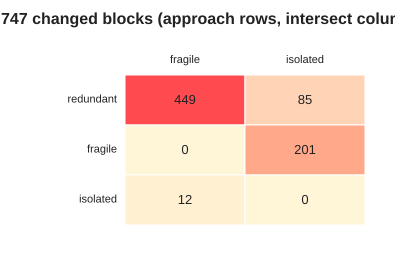

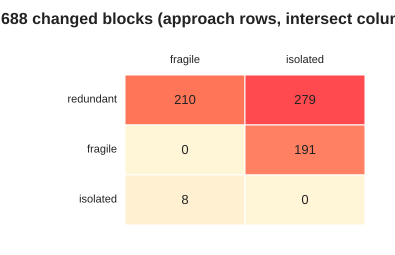

0 ft off-diagonal transitions


scenario_status,fragile,isolated
scenario_status,,
redundant,449,85
fragile,0,201
isolated,12,0


6 ft off-diagonal transitions


scenario_status,fragile,isolated
scenario_status,,
redundant,210,279
fragile,0,191
isolated,8,0


In [10]:
transition_tables = {}
for slr_ft in [0, 6]:
    a = long["approach"].xs(slr_ft, level="slr_ft")
    i = long["intersect"].xs(slr_ft, level="slr_ft")
    changed = a["scenario_status"].ne(i["scenario_status"])
    table = pd.crosstab(a.loc[changed, "scenario_status"], i.loc[changed, "scenario_status"])
    table = table.reindex(index=STATUS_ORDER, columns=STATUS_ORDER, fill_value=0)
    keep_rows = table.sum(axis=1).gt(0)
    keep_cols = table.sum(axis=0).gt(0)
    table = table.loc[keep_rows, keep_cols]
    transition_tables[slr_ft] = table
    heatmap(table, title=f"{slr_ft} ft: {changed.sum():,} changed blocks (approach rows, intersect columns)")

for slr_ft, table in transition_tables.items():
    print(f"{slr_ft} ft off-diagonal transitions")
    display(table)

## 6. Conclusions from the completed runs

The next cell prints the central quantities directly from the loaded data, keeping the conclusions tied to the run artifacts rather than hard-coded values.

In [11]:
r0 = removal_summary.set_index(["slr_ft", "rule"])
p0 = pairwise_impact.set_index(["slr_ft", "comparison"])
low_landing_0 = a0["landing_node_count"].lt(2)
approach_only_service = approach_only_0["highway_classes"].eq("service").sum()

print("1. TOTAL-COUNT DENOMINATOR")
print(f"   At 0 ft, approach/intersect/retain remove {r0.loc[(0,'approach'),'n_total_edges_removed']:,} / "
      f"{r0.loc[(0,'intersect'),'n_total_edges_removed']:,} / {r0.loc[(0,'retain'),'n_total_edges_removed']:,} total segments.")
print(f"   At 6 ft, all rules share {r0.loc[(6,'retain'),'n_non_bridge_edges_removed']:,} non-bridge removals; "
      f"bridge removals are {r0.loc[(6,'approach'),'n_bridge_edges_removed']:,} (approach), "
      f"{r0.loc[(6,'intersect'),'n_bridge_edges_removed']:,} (intersect), and 0 (retain).")

print("\n2. BRIDGE-ONLY DIFFERENCE")
print(f"   At 0 ft, approach removes {r0.loc[(0,'approach'),'n_bridge_structures_removed']:,} structures / "
      f"{r0.loc[(0,'approach'),'n_bridge_edges_removed']:,} edges, versus "
      f"{r0.loc[(0,'intersect'),'n_bridge_structures_removed']:,} structures / "
      f"{r0.loc[(0,'intersect'),'n_bridge_edges_removed']:,} edges under intersect.")
print(f"   At 6 ft, the corresponding values are {r0.loc[(6,'approach'),'n_bridge_structures_removed']:,} / "
      f"{r0.loc[(6,'approach'),'n_bridge_edges_removed']:,} and "
      f"{r0.loc[(6,'intersect'),'n_bridge_structures_removed']:,} / "
      f"{r0.loc[(6,'intersect'),'n_bridge_edges_removed']:,}.")

print("\n3. NON-NESTED DECISIONS")
print(f"   At 0 ft, {structure_overlap.loc[0,'approach_only']:,} structures are removed only by approach, "
      f"while {structure_overlap.loc[0,'intersect_only']:,} are removed only by intersect.")
print(f"   Approach always removes {low_landing_0.sum():,} structures with <2 total landing nodes "
      f"({a0.loc[low_landing_0,'n_bridge_edges'].sum():,} edges; "
      f"{a0.loc[low_landing_0,'total_length_m'].sum()/1000:,.2f} km).")
print(f"   Of the {len(approach_only_0):,} baseline approach-only structures, "
      f"{approach_only_service:,} are entirely highway=service.")

print("\n4. DOWNSTREAM ACCESS STATUS")
print(f"   Approach vs retain changes {p0.loc[(0,'approach vs retain'),'blocks_changed']:,} blocks at 0 ft "
      f"and {p0.loc[(6,'approach vs retain'),'blocks_changed']:,} at 6 ft.")
print(f"   Intersect vs retain changes {p0.loc[(0,'intersect vs retain'),'blocks_changed']:,} blocks at 0 ft "
      f"and {p0.loc[(6,'intersect vs retain'),'blocks_changed']:,} at 6 ft.")
print("   The redundant-block count is identical under approach and retain at every SLR level.")

print("\nBOTTOM LINE")
print("   Similar TOTAL road-removal counts do not imply similar bridge treatment. Non-bridge inundation dominates total counts.")
print("   Approach is much closer to retain in downstream block status, while intersect is the materially conservative sensitivity.")
print("   The <2-landing bridge-like components—predominantly service roads—are the highest-priority topology audit.")

1. TOTAL-COUNT DENOMINATOR
   At 0 ft, approach/intersect/retain remove 1,097 / 1,478 / 437 total segments.
   At 6 ft, all rules share 431,250 non-bridge removals; bridge removals are 1,578 (approach), 3,440 (intersect), and 0 (retain).

2. BRIDGE-ONLY DIFFERENCE
   At 0 ft, approach removes 200 structures / 660 edges, versus 464 structures / 1,041 edges under intersect.
   At 6 ft, the corresponding values are 575 / 1,578 and 1,408 / 3,440.

3. NON-NESTED DECISIONS
   At 0 ft, 91 structures are removed only by approach, while 355 are removed only by intersect.
   Approach always removes 98 structures with <2 total landing nodes (484 edges; 10.57 km).
   Of the 91 baseline approach-only structures, 78 are entirely highway=service.

4. DOWNSTREAM ACCESS STATUS
   Approach vs retain changes 22 blocks at 0 ft and 9 at 6 ft.
   Intersect vs retain changes 745 blocks at 0 ft and 681 at 6 ft.
   The redundant-block count is identical under approach and retain at every SLR level.

BOTTOM LIN

### Interpretation

1. **`Approach` is confirmed as the canonical rule.** All seven scenarios contain the expected 70,695 blocks and no legacy switch was active.
2. **The apparent convergence is a denominator effect.** At higher SLR, non-bridge inundation accounts for nearly every removed segment and is identical under all three rules. Bridge-only counts remain meaningfully different.
3. **`Approach` is not mechanically between `intersect` and `retain`.** It retains many geometrically intersecting causeways with dry landings, as intended, but it also removes bridge-like components with fewer than two total landing nodes even when they do not intersect water.
4. **Those low-landing components deserve a targeted audit.** Most baseline approach-only structures are `highway=service`; some enter the bridge-like set through a positive `layer` rather than an explicit bridge tag. They contribute many removed edges but little downstream access impact.
5. **For block classifications, `approach` is remarkably close to the retain-all upper bound.** The `intersect` rule produces the substantive conservative contrast. This supports reporting `approach` as the primary specification and `intersect`/`retain` as the sensitivity ladder, while documenting the topology audit of low-landing service structures.

## 7. Measurement-validity audit of the positive-layer reruns

This section tests the completed reruns against the defects in *Why the baseline fragility rate is not yet defensible*. It distinguishes validity of the run outputs from readiness of the downstream analysis scripts.

In [12]:
validation_columns = [
    "block_geoid", "slr_ft", "pop20", "land_area_m2",
    "analysis_eligible", "exclusion_reason", "scenario_status",
    "block_centroid_inundated", "block_centroid_unclassified",
    "block_centroid_isolated", "block_centroid_redundant",
    "block_centroid_fragile", "origin_snap_exceeds_threshold",
    "origin_in_lcc", "origin_geometry_method",
]
validation = {
    rule: pd.read_parquet(run_dir / "block_access_flags_long.parquet", columns=validation_columns)
    for rule, run_dir in RUN_DIRS.items()
}
flag_columns = [
    "block_centroid_inundated", "block_centroid_unclassified",
    "block_centroid_isolated", "block_centroid_redundant",
    "block_centroid_fragile",
]
comparison_rows = []
reference = validation["approach"].sort_values(["block_geoid", "slr_ft"]).reset_index(drop=True)
for rule, frame in validation.items():
    ordered = frame.sort_values(["block_geoid", "slr_ft"]).reset_index(drop=True)
    baseline_ordered = ordered.loc[ordered["slr_ft"].eq(0)]
    comparison_rows.append({
        "rule": rule,
        "rows": len(ordered),
        "blocks": ordered["block_geoid"].nunique(),
        "duplicate_keys": int(ordered.duplicated(["block_geoid", "slr_ft"]).sum()),
        "five_state_partition_violations": int(ordered[flag_columns].sum(axis=1).ne(1).sum()),
        "eligible_unclassified": int((ordered["analysis_eligible"] & ordered["scenario_status"].eq("unclassified")).sum()),
        "unclassified_and_inundated": int((ordered["block_centroid_unclassified"].eq(1) & ordered["block_centroid_inundated"].eq(1)).sum()),
        "inundation_mismatch_vs_approach": int(ordered["block_centroid_inundated"].ne(reference["block_centroid_inundated"]).sum()),
        "origins_outside_raw_lcc": int((~baseline_ordered["origin_in_lcc"]).sum()),
        "non_representative_origins": int(baseline_ordered["origin_geometry_method"].ne("representative_point").sum()),
        "origin_snap_failures": int(baseline_ordered["origin_snap_exceeds_threshold"].eq(1).sum()),
    })
comparability = pd.DataFrame(comparison_rows)
display(comparability)
assert not comparability[["duplicate_keys", "five_state_partition_violations", "eligible_unclassified", "unclassified_and_inundated", "inundation_mismatch_vs_approach", "origins_outside_raw_lcc", "non_representative_origins"]].to_numpy().any()

service = pd.read_csv(RUN_DIRS["approach"] / "service_snapping_audit.csv")
service_rows = []
for audit_universe, audit_frame in [("all_audit_records", service), ("valid_analysis_services", service.loc[service["snap_valid"]])]:
    for service_type, group in [("all", audit_frame), *audit_frame.groupby("service_type")]:
        singleton = group["service_raw_2ecc_size"].eq(1)
        service_rows.append({
            "audit_universe": audit_universe, "service_type": service_type,
            "services": len(group), "singleton_2ecc": int(singleton.sum()),
            "singleton_share_pct": 100 * singleton.mean(),
        })
service_validity = pd.DataFrame(service_rows)
display(service_validity)
moved = service.loc[service["service_node_moved"]]
display(pd.DataFrame([{
    "services_moved": len(moved),
    "added_distance_median": moved["service_snap_distance_penalty_m"].median(),
    "added_distance_p90": moved["service_snap_distance_penalty_m"].quantile(0.9),
    "added_distance_max": moved["service_snap_distance_penalty_m"].max(),
    "invalid_over_1000m": int((~service["snap_valid"]).sum()),
}]))

canonical_baseline = validation["approach"].loc[validation["approach"]["slr_ft"].eq(0)].copy()
zero_pop = canonical_baseline["pop20"].eq(0)
zero_land = canonical_baseline["land_area_m2"].eq(0)
analysis_universe = canonical_baseline["analysis_eligible"] & ~zero_pop & ~zero_land
universe_summary = pd.DataFrame([{
    "all_blocks": len(canonical_baseline),
    "pop20_eq_0": int(zero_pop.sum()),
    "land_area_eq_0": int(zero_land.sum()),
    "both_zero_pop_and_land": int((zero_pop & zero_land).sum()),
    "pipeline_analysis_eligible": int(canonical_baseline["analysis_eligible"].sum()),
    "origin_snap_failed": int(canonical_baseline["exclusion_reason"].eq("origin_snap_failed").sum()),
    "analysis_eligible_and_pop20_gt_0": int(analysis_universe.sum()),
    "population_in_analysis_universe": int(canonical_baseline.loc[analysis_universe, "pop20"].sum()),
}])
display(universe_summary)

baseline_rows = []
for rule, frame in validation.items():
    baseline = frame.loc[frame["slr_ft"].eq(0)]
    for universe_name, keep in [("all_blocks", pd.Series(True, index=baseline.index)), ("analysis_eligible_pop20_gt_0", baseline["analysis_eligible"] & baseline["pop20"].gt(0) & baseline["land_area_m2"].gt(0))]:
        counts = baseline.loc[keep, "scenario_status"].value_counts()
        baseline_rows.append({
            "rule": rule, "universe": universe_name, "blocks": int(keep.sum()),
            **{status: int(counts.get(status, 0)) for status in STATUS_ORDER},
            "fragile_share_pct": 100 * baseline.loc[keep, "scenario_status"].eq("fragile").mean(),
        })
baseline_validity = pd.DataFrame(baseline_rows)
display(baseline_validity)

,rule,rows,blocks,duplicate_keys,five_state_partition_violations,eligible_unclassified,unclassified_and_inundated,inundation_mismatch_vs_approach,origins_outside_raw_lcc,non_representative_origins,origin_snap_failures
0,approach,494865,70695,0,0,0,0,0,0,0,262
1,intersect,494865,70695,0,0,0,0,0,0,0,262
2,retain,494865,70695,0,0,0,0,0,0,0,262


,audit_universe,service_type,services,singleton_2ecc,singleton_share_pct
0,all_audit_records,all,2190,29,1.32
1,all_audit_records,fire_station,334,11,3.29
2,all_audit_records,school,1856,18,0.97
3,valid_analysis_services,all,2163,3,0.14
4,valid_analysis_services,fire_station,324,1,0.31
5,valid_analysis_services,school,1839,2,0.11


,services_moved,added_distance_median,added_distance_p90,added_distance_max,invalid_over_1000m
0,574,13.71,40.14,669.92,27


,all_blocks,pop20_eq_0,land_area_eq_0,both_zero_pop_and_land,pipeline_analysis_eligible,origin_snap_failed,analysis_eligible_and_pop20_gt_0,population_in_analysis_universe
0,70695,15284,2019,2002,68521,262,55381,6135688


,rule,universe,blocks,redundant,fragile,isolated,inundated,unclassified,fragile_share_pct
0,approach,all_blocks,70695,51452,17729,165,1178,171,25.08
1,approach,analysis_eligible_pop20_gt_0,55381,40439,14706,143,93,0,26.55
2,intersect,all_blocks,70695,50918,17989,439,1178,171,25.45
3,intersect,analysis_eligible_pop20_gt_0,55381,40112,14801,375,93,0,26.73
4,retain,all_blocks,70695,51452,17751,143,1178,171,25.11
5,retain,analysis_eligible_pop20_gt_0,55381,40439,14722,127,93,0,26.58


### What moved relative to the published pre-fix baseline

Because several corrections act simultaneously, a direct transition table is more informative than assuming the fragile share must fall.

In [13]:
diag_path = PROJECT_ROOT / "scripts" / "02b_diagnose_access_run.py"
diag_spec = importlib.util.spec_from_file_location("diag02b_for_notebook", diag_path)
diag02b = importlib.util.module_from_spec(diag_spec)
assert diag_spec.loader is not None
diag_spec.loader.exec_module(diag02b)
pre_fix_dir = PROJECT_ROOT / "data" / "processed" / "access" / "edited" / "2026-04-03_run"
pre_fix, pre_fix_duplicate_rows = diag02b.load_and_combine_results(diag02b.find_result_files(pre_fix_dir))
pre_fix_baseline = pre_fix.loc[pre_fix["slr_ft"].eq(0), ["block_geoid", "scenario_status"]].rename(columns={"scenario_status": "pre_fix_status"})
corrected_baseline = canonical_baseline[["block_geoid", "scenario_status", "pop20", "land_area_m2", "analysis_eligible"]].rename(columns={"scenario_status": "corrected_status"})
baseline_change = pre_fix_baseline.merge(corrected_baseline, on="block_geoid", validate="one_to_one")
display(pd.crosstab(baseline_change["pre_fix_status"], baseline_change["corrected_status"], margins=True))
analysis_keep = baseline_change["analysis_eligible"] & baseline_change["pop20"].gt(0) & baseline_change["land_area_m2"].gt(0)
display(pd.crosstab(baseline_change.loc[analysis_keep, "pre_fix_status"], baseline_change.loc[analysis_keep, "corrected_status"], margins=True))
fragile_change = pd.DataFrame([
    {"universe": "all_blocks", "pre_fix_pct": 100 * baseline_change["pre_fix_status"].eq("fragile").mean(), "corrected_approach_pct": 100 * baseline_change["corrected_status"].eq("fragile").mean()},
    {"universe": "analysis_eligible_pop20_gt_0", "pre_fix_pct": 100 * baseline_change.loc[analysis_keep, "pre_fix_status"].eq("fragile").mean(), "corrected_approach_pct": 100 * baseline_change.loc[analysis_keep, "corrected_status"].eq("fragile").mean()},
])
fragile_change["change_percentage_points"] = fragile_change["corrected_approach_pct"] - fragile_change["pre_fix_pct"]
display(fragile_change)

corrected_status,fragile,inundated,isolated,redundant,unclassified,All
pre_fix_status,,,,,,
fragile,15080,91,9,2270,8,17458
inundated,53,983,6,50,3,1095
isolated,1013,56,148,1097,156,2470
redundant,1583,48,2,48035,4,49672
All,17729,1178,165,51452,171,70695


corrected_status,fragile,inundated,isolated,redundant,All
pre_fix_status,,,,,
fragile,12613,25,7,1675,14320
inundated,43,41,4,38,126
isolated,819,7,131,888,1845
redundant,1231,20,1,37838,39090
All,14706,93,143,40439,55381


,universe,pre_fix_pct,corrected_approach_pct,change_percentage_points
0,all_blocks,24.69,25.08,0.38
1,analysis_eligible_pop20_gt_0,25.86,26.55,0.70


### Positive-layer and bridge-removal validation

The local v2 edge cache is reclassified in memory only. The resulting structure inventory is checked against the Della audit before it is used to measure 0 ft and 1 ft removals.

In [14]:
assert cache_paths, "A local segmentized-edge cache is required for the layer-gate audit."
positive_bridge_like = cached_edges["bridge_like"].astype(bool)
gate_change = cached_bridge_like_before_positive_gate.ne(positive_bridge_like)
layer_numeric = pd.to_numeric(cached_edges["layer_value"], errors="coerce")
structured_positive, structures_positive, positive_landings = base.build_bridge_structures(cached_edges)
della_structure_audit = pd.read_csv(RUN_DIRS["approach"] / "bridge_structures_slr_0ft.csv").sort_values("structure_id").reset_index(drop=True)
local_structures = structures_positive.sort_values("structure_id").reset_index(drop=True)
structure_match = (
    len(local_structures) == len(della_structure_audit)
    and local_structures["n_bridge_edges"].equals(della_structure_audit["n_bridge_edges"])
    and np.allclose(local_structures["total_length_m"], della_structure_audit["total_length_m"])
)
display(pd.DataFrame([{
    "legacy_bridge_like_edges": int(cached_bridge_like_before_positive_gate.sum()),
    "positive_gate_bridge_like_edges": int(positive_bridge_like.sum()),
    "classification_changes": int(gate_change.sum()),
    "changed_negative_layer_edges": int((gate_change & layer_numeric.lt(0)).sum()),
    "della_structure_inventory_matches": structure_match,
    "physical_structures": len(local_structures),
}]))
assert structure_match

from shapely.geometry import box
bridge_removal_rows = []
clip_polygon = box(*structured_positive.total_bounds)
for slr_ft, layer_name in [(0, base.BASELINE_SLR_LAYER), (1, base.SLR_LAYER_MAP[1])]:
    slr_layer = base.load_slr_layer(layer_name, clip_polygon)
    intersect_positions = set(base.query_intersecting_positions(structured_positive, slr_layer.geometry).tolist())
    bridge_array = structured_positive["bridge_like"].to_numpy(dtype=bool)
    non_bridge_positions = {position for position in intersect_positions if not bridge_array[position]}
    approach_audit = pd.read_csv(RUN_DIRS["approach"] / f"bridge_structures_slr_{slr_ft}ft.csv")
    approach_removed_structures = set(approach_audit.loc[approach_audit["removed"], "structure_id"].astype(int))
    approach_bridge_positions = set(np.flatnonzero(structured_positive["bridge_like"] & structured_positive["structure_id"].isin(approach_removed_structures)).tolist())
    positions_by_rule = {
        "intersect": intersect_positions,
        "approach": non_bridge_positions | approach_bridge_positions,
        "retain": non_bridge_positions,
    }
    for rule, positions in positions_by_rule.items():
        removed = structured_positive.iloc[sorted(positions)]
        removed_layer = pd.to_numeric(removed["layer_value"], errors="coerce")
        bridge_removal_rows.append({
            "slr_ft": slr_ft, "rule": rule,
            "removed_segments": len(removed), "removed_length_km": removed["length_m"].sum() / 1000,
            "bridge_like_segments": int(removed["bridge_like"].sum()),
            "bridge_like_length_km": removed.loc[removed["bridge_like"], "length_m"].sum() / 1000,
            "negative_layer_segments_removed": int(removed_layer.lt(0).sum()),
            "negative_layer_length_km": removed.loc[removed_layer.lt(0), "length_m"].sum() / 1000,
        })
bridge_removal_validity = pd.DataFrame(bridge_removal_rows)
display(bridge_removal_validity)

,legacy_bridge_like_edges,positive_gate_bridge_like_edges,classification_changes,changed_negative_layer_edges,della_structure_inventory_matches,physical_structures
0,12170,10734,1436,1436,True,3482


,slr_ft,rule,removed_segments,removed_length_km,bridge_like_segments,bridge_like_length_km,negative_layer_segments_removed,negative_layer_length_km
0,0,intersect,1478,77.43,1041,56.16,9,1.39
1,0,approach,1097,38.04,660,16.78,9,1.39
2,0,retain,437,21.26,0,0.00,9,1.39
3,1,intersect,1872,97.14,1074,57.05,9,1.39
4,1,approach,1461,56.97,663,16.88,9,1.39
5,1,retain,798,40.09,0,0.00,9,1.39


## 8. Audit verdict

**The measurement corrections pass, and the `approach` output is suitable as the corrected analysis input.** Service attachment, bridge handling, the positive-layer gate, origin-failure classification, five-state partitioning, and block eligibility all behave as specified. The `intersect` and `retain` runs are valid sensitivity bounds.

Three qualifications remain before final manuscript numbers are regenerated:

1. The corrected baseline fragile share does **not** fall: it is about 25.08% across all blocks and 26.55% in the eligible, populated universe. The direct transition table shows that origin/LCC corrections move many formerly isolated blocks into reachable fragile or redundant states; this is an empirical result, not evidence that the service fix failed.
2. The Della manifests record commit `27ac074` with a dirty working tree. Archive or verify the exact Della `02_access_flags.py` SHA-256 before treating this as the final reproducible run.
3. Downstream construction/model/figure code must explicitly keep `analysis_eligible & pop20 > 0 & land_area_m2 > 0` and handle `unclassified`; the corrected run files alone do not make the old downstream scripts safe. `02g_compare_bridge_rule_runs.py` also has a known one-edge expectation mismatch because it excludes `bridge=movable`, while the pipeline deliberately keeps movable tags bridge-like.